# Notebook 06: Decision Engine

**Purpose:** Convert model probability scores into business recommendations (APPROVE / DECLINE / REFER) using calibrated thresholds and hard business rules.

## Architecture

```
New Application
      │
      ▼
[HARD RULES CHECK]
 R001: DPD > 60?                              ──► DECLINE
 R002: Bureau score < 300?                    ──► DECLINE
 R003: Repeat defaulter (2+ loans)?           ──► DECLINE
 R004: LTR > 5x?                              ──► REFER
 R005: Age < 18?                              ──► DECLINE
 R006: Prior default + bureau score < 450?    ──► DECLINE
      │ (no rules triggered)
      ▼
[MODEL SCORE CHECK]
 score < approve_threshold  ──► APPROVE
 score > decline_threshold  ──► DECLINE
 else                       ──► REFER
      │
      ▼
[LOG DECISION + REASON + SHAP EXPLANATION]
```

## Why Hard Rules AND a Model?
Models give probabilities. Some business situations have binary policy answers:
- A borrower 90 days past due is in active financial distress → no probability changes this
- Hard rules handle bright-line cases; the model handles probabilistic uncertainty
- Defense in depth: the model is the primary decision-maker, hard rules are the safety net

## Why min_decline_pct as a Policy Constraint?
With Gini ≈ 0.22, the model's score distribution clusters near the 13.3% base rate.
A pure cost-minimising sweep produces a 0.90 decline threshold that almost never fires (0.3% DECLINE).
We add `min_decline_pct=0.10` as a **credit-committee policy constraint** — separate from the model.
The break-even default rate in the declined pool is 1 / (1 + 4) = **20%**.
If the actual default rate in our declined bucket exceeds 20%, the constraint is also cost-justified.

In [1]:
# ── CELL 1: Environment setup ──────────────────────────────────────────────────
import sys, os, json, importlib

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/stanbic_sme_credit'
except ImportError:
    IN_COLAB = False
    _search = os.getcwd()
    BASE_PATH = _search
    for _ in range(3):
        if os.path.isdir(os.path.join(BASE_PATH, 'src')):
            break
        BASE_PATH = os.path.dirname(BASE_PATH)

sys.path.insert(0, os.path.join(BASE_PATH, 'src'))
env_str = 'Google Colab' if IN_COLAB else 'Local Jupyter'
print(f'Environment : {env_str}')
print(f'Base path   : {BASE_PATH}')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Force reload so Colab always picks up the latest file from Drive
# (without this, Python caches the first import and ignores any re-uploaded file)
import decision_engine as _de_module
importlib.reload(_de_module)
from decision_engine import SMECreditDecisionEngine

from preprocessing import TARGET

PROCESSED    = f'{BASE_PATH}/data/processed'
MODELS_PATH  = f'{BASE_PATH}/models'
FIGURES_PATH = f'{BASE_PATH}/reports/figures'
print('Environment ready.')
print(f'decision_engine loaded from: {_de_module.__file__}')

Mounted at /content/drive
Environment : Google Colab
Base path   : /content/drive/MyDrive/stanbic_sme_credit
Environment ready.
decision_engine loaded from: /content/drive/MyDrive/stanbic_sme_credit/src/decision_engine.py


In [2]:
# ── CELL 2: Load data and winning model from registry ─────────────────────────
import numpy as np
X_test  = pd.read_csv(f'{PROCESSED}/X_test.csv', index_col=0)
y_test  = pd.read_csv(f'{PROCESSED}/y_test.csv', index_col=0).squeeze('columns')
y_prob  = pd.read_csv(f'{PROCESSED}/y_prob_test.csv', index_col=0).squeeze('columns')

X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

with open(f'{MODELS_PATH}/model_registry.json') as f:
    registry = json.load(f)

winning_model_name = registry.get('winning_model', 'logistic_regression_v1')
winning_model = joblib.load(f'{MODELS_PATH}/{winning_model_name}.pkl')

# For single-application inference demo, get the underlying sklearn pipeline.
# Stacking is a StackingClassifier (also a sklearn estimator) — it works
# the same way for predict_proba, so no special handling needed.
print(f'Winning model: {winning_model_name}')
print(f'Test set: {len(X_test):,} applications')
print(f'Probability scores loaded: {len(y_prob):,}')
print(f'Model type: {type(winning_model).__name__}')


Winning model: logistic_regression_v1
Test set: 608 applications
Probability scores loaded: 608
Model type: Pipeline


## Step 1: Calibrate Thresholds Using Business Cost Matrix

In [3]:
# ── CELL 3: Business cost analysis ────────────────────────────────────────────
print('BUSINESS COST MODEL:')
print('=' * 55)
print('''
Typical Stanbic SME loan:
  Loan amount    : GHS 100,000
  Interest rate  : 22% per year
  Tenor          : 12 months

Cost of a FALSE NEGATIVE (approved loan that defaults):
  Bank disburses GHS 100,000
  Recovery on default: ~20% (collateral + recovery costs)
  Net loss: GHS 100,000 × (1 - 0.20) = GHS 80,000

Cost of a FALSE POSITIVE (declined good customer):
  Bank foregoes interest income
  Foregone revenue: GHS 100,000 × 22% = GHS 22,000

Cost ratio FN/FP = 80,000 / 22,000 ≈ 3.6x → round to 4x
This means: catching one missed default is worth declining ~4 good customers
''')

FN_COST_MULTIPLIER = 4.0
print(f'Using fn_cost_multiplier = {FN_COST_MULTIPLIER}')

BUSINESS COST MODEL:

Typical Stanbic SME loan:
  Loan amount    : GHS 100,000
  Interest rate  : 22% per year
  Tenor          : 12 months

Cost of a FALSE NEGATIVE (approved loan that defaults):
  Bank disburses GHS 100,000
  Recovery on default: ~20% (collateral + recovery costs)
  Net loss: GHS 100,000 × (1 - 0.20) = GHS 80,000

Cost of a FALSE POSITIVE (declined good customer):
  Bank foregoes interest income
  Foregone revenue: GHS 100,000 × 22% = GHS 22,000

Cost ratio FN/FP = 80,000 / 22,000 ≈ 3.6x → round to 4x
This means: catching one missed default is worth declining ~4 good customers

Using fn_cost_multiplier = 4.0


In [4]:
# ── CELL 4: Run threshold calibration ─────────────────────────────────────────
# BASELINE (unconstrained): shows what pure cost minimisation produces
print('── BASELINE (no policy constraints) ──')
_, _, baseline_df = SMECreditDecisionEngine.calibrate_thresholds(
    y_prob.values, y_test.values,
    fn_cost_multiplier=FN_COST_MULTIPLIER,
    min_refer_pct=0.10,
    max_refer_pct=0.60,
)

print()
print('── POLICY-CONSTRAINED (recommended for production) ──')
# min_decline_pct=0.10 : credit committee requires at least 10% auto-declines
# max_approve_pct=0.50 : cap auto-approvals at 50% regardless of model confidence
# max_refer_pct=0.50   : tighten from 0.60 — force more auto-decisions
opt_approve, opt_decline, threshold_df = SMECreditDecisionEngine.calibrate_thresholds(
    y_prob.values, y_test.values,
    fn_cost_multiplier=FN_COST_MULTIPLIER,
    min_refer_pct=0.10,
    max_refer_pct=0.50,
    min_decline_pct=0.10,
    max_approve_pct=0.50,
)

print(f'\nFinal calibrated thresholds (policy-constrained):')
print(f'  APPROVE if score < {opt_approve}')
print(f'  DECLINE if score > {opt_decline}')
print(f'  REFER otherwise')

── BASELINE (no policy constraints) ──
OPTIMAL THRESHOLDS (business cost minimisation):
  approve_threshold : 0.4  (APPROVE if score < this)
  decline_threshold : 0.65  (DECLINE if score > this)
  business_cost     : 122
  FN (missed defaults) : 18
  FP (wrongly declined): 50
  APPROVE rate      : 30.6%
  REFER rate        : 59.2%
  DECLINE rate      : 10.2%

DECLINE ZONE QUALITY:
  Actual default rate in declined pool : 19.4%
  Break-even default rate (1/(1+4)): 20.0%
  Assessment : POLICY-COST (below break-even)

── POLICY-CONSTRAINED (recommended for production) ──
OPTIMAL THRESHOLDS (business cost minimisation):
  approve_threshold : 0.45  (APPROVE if score < this)
  decline_threshold : 0.65  (DECLINE if score > this)
  business_cost     : 174
  FN (missed defaults) : 31
  FP (wrongly declined): 50
  APPROVE rate      : 49.5%
  REFER rate        : 40.3%
  DECLINE rate      : 10.2%

DECLINE ZONE QUALITY:
  Actual default rate in declined pool : 19.4%
  Break-even default rate (1/(1+

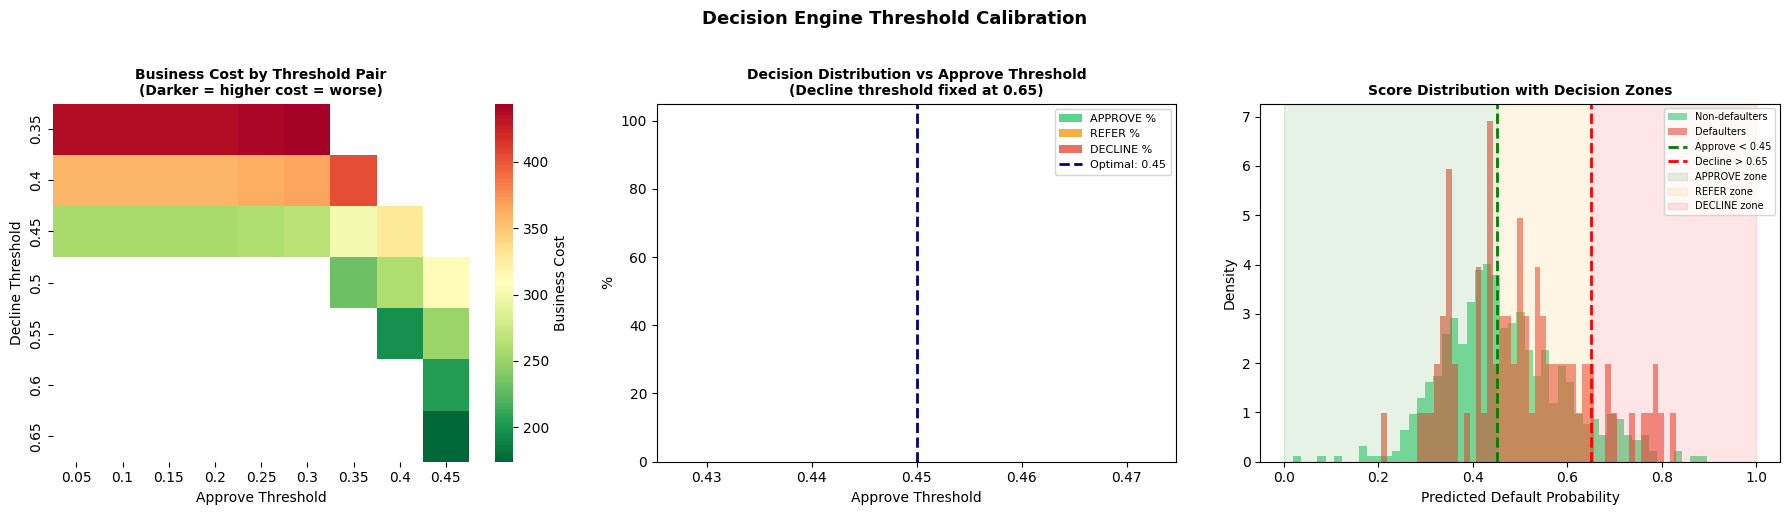

In [5]:
# ── CELL 5: Visualise threshold landscape ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Business cost heatmap (approve vs decline threshold)
ax = axes[0]
pivot = threshold_df.pivot_table(
    index='decline_threshold', columns='approve_threshold', values='business_cost'
)
sns.heatmap(pivot, cmap='RdYlGn_r', ax=ax, annot=False, cbar_kws={'label': 'Business Cost'})
ax.set_title('Business Cost by Threshold Pair\n(Darker = higher cost = worse)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Approve Threshold')
ax.set_ylabel('Decline Threshold')

# Plot 2: Recommendation distribution by approve threshold (holding decline fixed)
ax = axes[1]
fixed_decline = opt_decline
filtered = threshold_df[threshold_df['decline_threshold'] == fixed_decline].sort_values('approve_threshold')
if len(filtered) > 0:
    ax.stackplot(
        filtered['approve_threshold'],
        filtered['approve_pct'] * 100,
        filtered['refer_pct']   * 100,
        filtered['decline_pct'] * 100,
        labels=['APPROVE %', 'REFER %', 'DECLINE %'],
        colors=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8
    )
    ax.axvline(opt_approve, color='navy', linestyle='--', lw=2,
               label=f'Optimal: {opt_approve}')
    ax.set_xlabel('Approve Threshold')
    ax.set_ylabel('%')
    ax.set_title(f'Decision Distribution vs Approve Threshold\n(Decline threshold fixed at {fixed_decline})',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

# Plot 3: Score distribution with threshold zones
ax = axes[2]
ax.hist(y_prob[y_test == 0], bins=50, alpha=0.6, color='#2ecc71',
        label='Non-defaulters', density=True)
ax.hist(y_prob[y_test == 1], bins=50, alpha=0.6, color='#e74c3c',
        label='Defaulters', density=True)
ax.axvline(opt_approve, color='green', lw=2, linestyle='--',
           label=f'Approve < {opt_approve}')
ax.axvline(opt_decline, color='red',   lw=2, linestyle='--',
           label=f'Decline > {opt_decline}')
ax.axvspan(0,           opt_approve, alpha=0.1, color='green', label='APPROVE zone')
ax.axvspan(opt_approve, opt_decline, alpha=0.1, color='orange', label='REFER zone')
ax.axvspan(opt_decline, 1.0,         alpha=0.1, color='red',   label='DECLINE zone')
ax.set_xlabel('Predicted Default Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution with Decision Zones', fontsize=10, fontweight='bold')
ax.legend(fontsize=7)

plt.suptitle('Decision Engine Threshold Calibration', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/13_threshold_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2: Initialise Decision Engine with Calibrated Thresholds

In [6]:
# ── CELL 6: Create Decision Engine with calibrated thresholds ──────────────────
engine = SMECreditDecisionEngine(
    approve_threshold=opt_approve,
    decline_threshold=opt_decline
)

print('Decision Engine configured:')
config = engine.get_config()
print(f"  approve_threshold : {config['approve_threshold']}")
print(f"  decline_threshold : {config['decline_threshold']}")
print(f'\nHard Rules:')
for rule_id, description in config['hard_rules'].items():
    print(f'  {rule_id}: {description}')

Decision Engine configured:
  approve_threshold : 0.45
  decline_threshold : 0.65

Hard Rules:
  R001: days_past_due_current > 60 → DECLINE
  R002: credit_bureau_score < 300 → DECLINE
  R003: previous_default=Yes AND previous_loan_count > 1 → DECLINE
  R004: loan_amount / annual_revenue > 5 → REFER
  R005: owner_age < 18 → DECLINE
  R006: previous_default=Yes AND credit_bureau_score < 450 → DECLINE


In [7]:
# ── CELL 7: Apply engine to test set ──────────────────────────────────────────
decisions_df = engine.evaluate_on_test_set(y_prob.values, X_test, y_test)

DECISION ENGINE — Test Set Results
Total applications evaluated: 608

Recommendation Distribution:
  APPROVE    :  301  ( 49.5%)  ████████████████████████
  REFER      :  245  ( 40.3%)  ████████████████████
  DECLINE    :   62  ( 10.2%)  █████

Quality Validation (actual default rate per recommendation):
  APPROVE    : n= 301  actual default rate=10.3%
               Quality: REVIEW THRESHOLD
  REFER      : n= 245  actual default rate=15.5%
               Quality: OK
  DECLINE    : n=  62  actual default rate=19.4%
               Quality: REVIEW THRESHOLD

Hard rule overrides: 0 (0.0% of decisions)


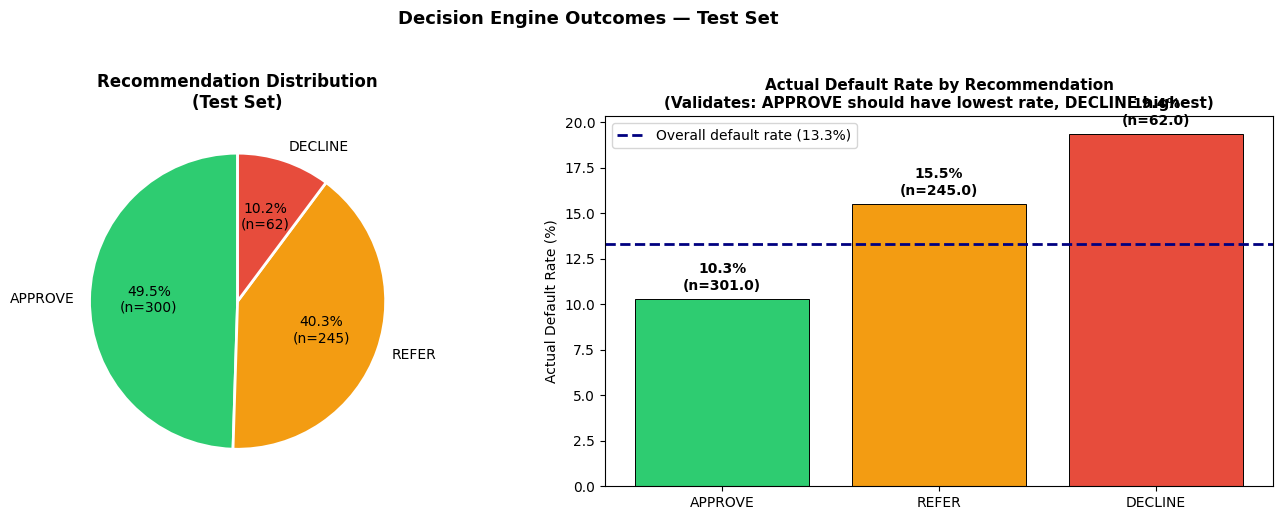

In [8]:
# ── CELL 8: Decision distribution chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: overall distribution
dist = decisions_df['recommendation'].value_counts()
colors = {'APPROVE': '#2ecc71', 'REFER': '#f39c12', 'DECLINE': '#e74c3c'}
pie_colors = [colors.get(r, 'gray') for r in dist.index]
axes[0].pie(dist, labels=dist.index, colors=pie_colors,
            autopct=lambda p: f'{p:.1f}%\n(n={int(p*len(decisions_df)/100)})',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Recommendation Distribution\n(Test Set)', fontsize=12, fontweight='bold')

# Bar chart: actual default rate per recommendation
summary = decisions_df.groupby('recommendation')['actual_default'].agg(['mean', 'count']).reset_index()
summary = (summary
           .set_index('recommendation')
           .reindex(['APPROVE', 'REFER', 'DECLINE'])
           .fillna({'mean': 0.0, 'count': 0}))  # NaN = bucket has 0 applications
summary['count'] = summary['count'].astype(int)

bar_colors = [colors.get(r, 'gray') for r in summary.index]
bars = axes[1].bar(summary.index, summary['mean'] * 100, color=bar_colors,
                   edgecolor='black', linewidth=0.7)
axes[1].axhline(y_test.mean() * 100, color='navy', linestyle='--', lw=2,
                label=f'Overall default rate ({y_test.mean():.1%})')
axes[1].set_ylabel('Actual Default Rate (%)')
axes[1].set_title('Actual Default Rate by Recommendation\n'
                  '(Validates: APPROVE should have lowest rate, DECLINE highest)',
                  fontsize=11, fontweight='bold')
axes[1].legend()
for bar, (idx, row) in zip(bars, summary.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{row['mean']:.1%}\n(n={row['count']})",
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Decision Engine Outcomes — Test Set', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/14_decision_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Hard Rules Analysis

In [9]:
# ── CELL 9: Hard rule violations breakdown ────────────────────────────────────
hard_rule_decisions = decisions_df[decisions_df['hard_rule_triggered'] == True]

print(f'Applications overridden by hard rules: {len(hard_rule_decisions)} ({len(hard_rule_decisions)/len(decisions_df):.1%})')
print()

if len(hard_rule_decisions) > 0:
    violations_df = engine.get_hard_rules_summary()
    if len(violations_df) > 0:
        print('Hard Rule Violation Breakdown:')
        print(violations_df.groupby(['rule_id', 'decision']).size().reset_index(name='count').to_string(index=False))

print()
print('Hard rule validation (did rules catch real defaults?):')
print(hard_rule_decisions.groupby('recommendation')['actual_default'].agg(['mean', 'count']).to_string())

Applications overridden by hard rules: 0 (0.0%)


Hard rule validation (did rules catch real defaults?):
Empty DataFrame
Columns: [mean, count]
Index: []


## Step 4: Single Application Demo

This demonstrates the end-to-end inference pipeline — the key deliverable of the preprocessing requirement.

In [10]:
# ── CELL 10: End-to-end single application inference ──────────────────────────
from preprocessing import preprocess_single_application

# Simulate a new loan application arriving at the bank
new_application = {
    'sector':                       'Retail/Trading',
    'region':                       'Greater Accra',
    'ethnic_group':                 'Akan',
    'years_in_operation':           3.5,
    'owner_gender':                 'Female',
    'owner_age':                    38,
    'disability_status':            'No',
    'num_employees':                4,
    'annual_revenue_ghs':           'GHS 95,000',     # will be cleaned
    'monthly_momo_volume_ghs':      12000,
    'avg_monthly_bank_balance_ghs': 8500,
    'bank_account_tenure_months':   36,
    'has_momo_account':             'yes',            # will be standardised
    'gra_tin':                      'GH-987654321',  # valid TIN
    'loan_amount_requested_ghs':    45000,
    'loan_purpose':                 'Business Expansion',
    'collateral_type':              'Property',
    'collateral_value_ghs':         70000,
    'previous_loan_count':          1,
    'previous_default':             'No',
    'credit_bureau_score':          620,
    'application_date':             '03/15/2025',
    'days_past_due_current':        0,
}

# Step 1: Preprocess
X_single = preprocess_single_application(new_application)
print('Preprocessed feature vector (first 5 features):')
print(X_single.iloc[0, :5].to_string())

# Step 2: Predict probability
prob = winning_model.predict_proba(X_single)[0, 1]
print(f'\nPredicted default probability: {prob:.4f}')

# Step 3: Decision Engine
decision = engine.decide(prob, new_application)

print(f'\nDECISION ENGINE RESULT:')
print(f'  Recommendation : {decision["recommendation"]}')
print(f'  Score          : {decision["probability_score"]:.4f}')
print(f'  Reason         : {decision["reason"]}')
print(f'  Hard rule?     : {decision["hard_rule_triggered"]}')
print(f'  Timestamp      : {decision["timestamp"]}')

clean_dataframe: 1 rows processed, 0 total null values remaining
engineer_features: 22 new columns added
Preprocessed feature vector (first 5 features):
years_in_operation                   3.5
owner_age                             38
num_employees                          4
log_annual_revenue_ghs         11.461643
log_monthly_momo_volume_ghs     9.392745

Predicted default probability: 0.4679

DECISION ENGINE RESULT:
  Recommendation : REFER
  Score          : 0.4679
  Reason         : Score 0.4679 in uncertain zone [0.45, 0.65] — requires human review
  Hard rule?     : False
  Timestamp      : 2026-05-02T06:04:57.703417


In [11]:
# ── CELL 11: Demo — applications that trigger hard rules ───────────────────────

# ── Demo A: R001 + R003 (severe delinquency + repeat defaulter) ───────────────
hard_rule_app_a = {
    **new_application,
    'days_past_due_current': 75,   # triggers R001 (DPD > 60)
    'previous_default': 'Yes',
    'previous_loan_count': 2,      # triggers R003 (repeat defaulter)
}

X_a = preprocess_single_application(hard_rule_app_a)
prob_a = winning_model.predict_proba(X_a)[0, 1]
decision_a = engine.decide(prob_a, hard_rule_app_a)

print('DEMO A — Severe Delinquency + Repeat Defaulter (R001 + R003):')
print(f'  Model score    : {prob_a:.4f}  (ignored — hard rule fires first)')
print(f'  Recommendation : {decision_a["recommendation"]}')
print(f'  Rule ID        : {decision_a["rule_id"]}')
print(f'  Reason         : {decision_a["reason"]}')

print()

# ── Demo B: R006 (first-time defaulter + weak bureau score) ───────────────────
# R003 would NOT fire here (only 1 prior loan). R006 catches the combination
# that R003 misses: single default + low bureau score = chronic credit weakness.
hard_rule_app_b = {
    **new_application,
    'days_past_due_current': 0,    # DPD is fine — R001 does NOT fire
    'previous_default': 'Yes',
    'previous_loan_count': 1,      # only 1 loan — R003 does NOT fire
    'credit_bureau_score': 420,    # below 450 — R006 FIRES
}

X_b = preprocess_single_application(hard_rule_app_b)
prob_b = winning_model.predict_proba(X_b)[0, 1]
decision_b = engine.decide(prob_b, hard_rule_app_b)

print('DEMO B — First-time Defaulter + Weak Bureau Score (R006):')
print(f'  Model score    : {prob_b:.4f}  (ignored — hard rule fires first)')
print(f'  Recommendation : {decision_b["recommendation"]}')
print(f'  Rule ID        : {decision_b["rule_id"]}')
print(f'  Reason         : {decision_b["reason"]}')
print()
print('NOTE: previous_loan_count=1 means R003 (repeat defaulter) does NOT fire.')
print('      R006 catches the combination R003 misses: one default + low bureau score.')

clean_dataframe: 1 rows processed, 0 total null values remaining
engineer_features: 22 new columns added
DEMO A — Severe Delinquency + Repeat Defaulter (R001 + R003):
  Model score    : 0.7098  (ignored — hard rule fires first)
  Recommendation : DECLINE
  Rule ID        : R001, R003
  Reason         : days_past_due_current=75 exceeds 60-day threshold; previous_default=Yes with 2 prior loans

clean_dataframe: 1 rows processed, 0 total null values remaining
engineer_features: 22 new columns added
DEMO B — First-time Defaulter + Weak Bureau Score (R006):
  Model score    : 0.7195  (ignored — hard rule fires first)
  Recommendation : DECLINE
  Rule ID        : R006
  Reason         : previous_default=Yes with credit_bureau_score=420 (below 450 caution threshold)

NOTE: previous_loan_count=1 means R003 (repeat defaulter) does NOT fire.
      R006 catches the combination R003 misses: one default + low bureau score.


In [12]:
# ── CELL 12: Save decisions and update registry ────────────────────────────────
decisions_df.to_csv(f'{PROCESSED}/decisions_test.csv', index=False)

# Update model registry with decision engine config
with open(f'{MODELS_PATH}/model_registry.json') as f:
    registry = json.load(f)

registry['decision_engine'] = {
    'approve_threshold':  opt_approve,
    'decline_threshold':  opt_decline,
    'fn_cost_multiplier': FN_COST_MULTIPLIER,
    'hard_rules':         6,
    'calibration':        'policy-constrained (min_decline_pct=0.10, max_approve_pct=0.50)',
    'approve_rate':       float(decisions_df['recommendation'].eq('APPROVE').mean()),
    'refer_rate':         float(decisions_df['recommendation'].eq('REFER').mean()),
    'decline_rate':       float(decisions_df['recommendation'].eq('DECLINE').mean()),
}

with open(f'{MODELS_PATH}/model_registry.json', 'w') as f:
    json.dump(registry, f, indent=2)

print('Saved: decisions_test.csv')
print('Updated: model_registry.json')
print()
print('Decision Engine summary:')
print(f'  Hard rules     : 6 (R001–R006)')
print(f'  Approve < {opt_approve}    Decline > {opt_decline}')
print(f'  APPROVE {decisions_df["recommendation"].eq("APPROVE").mean():.1%}  '
      f'REFER {decisions_df["recommendation"].eq("REFER").mean():.1%}  '
      f'DECLINE {decisions_df["recommendation"].eq("DECLINE").mean():.1%}')
print()
print('Proceed to notebook 07_ethics_explainability.ipynb')

Saved: decisions_test.csv
Updated: model_registry.json

Decision Engine summary:
  Hard rules     : 6 (R001–R006)
  Approve < 0.45    Decline > 0.65
  APPROVE 49.5%  REFER 40.3%  DECLINE 10.2%

Proceed to notebook 07_ethics_explainability.ipynb
